# Ontologie des vertus argumentatives -- le pole miroir des sophismes (SKOS + AIF)

Le projet [Argumentum](https://www.argumentum.games/) modelise l'argumentation sur **deux poles** :

- le pole **negatif** -- les *sophismes* (fallacies), explore dans le notebook compagnon
  [`Argument_Analysis_Ontology_AIF`](Argument_Analysis_Ontology_AIF.ipynb) : une ontologie OWL2
  a base de `NamedIndividual` reliees par un graphe dense d'`ObjectPropertyAssertion` ;
- le pole **positif** -- les *vertus* argumentatives (virtues), objet de ce notebook.

L'ontologie des vertus (`argumentum_virtues.owl`) se decrit elle-meme comme
*"the mirror of the fallacies axis (223 nodes, 7 families)"*. Mais son **paradigme de
modelisation est different** : la ou les sophismes sont des individus (ABox), les vertus
forment un **thesaurus SKOS** (`skos:Concept`, `skos:broader`/`skos:narrower`,
`skos:prefLabel`, `skos:definition`) -- une organisation de connaissances hierarchique et
multilingue. Un meme projet, deux choix de modelisation opposes : c'est la lecon centrale
de ce notebook.

Le lien entre les deux poles est la propriete AIF `aif:goodTenorOf` (le *bon tenor* d'un
schema d'argument de Walton), miroir exact du `badTenorOf` cote sophismes.

**Objectifs pedagogiques**
1. Charger une ontologie OWL/XML que `rdflib` ne parse pas nativement, via un pont vers un graphe RDF.
2. Interroger un thesaurus SKOS avec **SPARQL** (hierarchie, langues, schemes).
3. Comprendre le contraste **ABox (individus) vs thesaurus SKOS (concepts)** entre deux ontologies soeurs.


## 1. SKOS, AIF et le format OWL/XML

**SKOS** ([Simple Knowledge Organization System](https://www.w3.org/TR/skos-reference/), W3C 2009)
est le vocabulaire standard pour publier des thesaurus, taxonomies et systemes de classification
sur le web semantique. Ses primitives :

| Primitive SKOS | Role |
|----------------|------|
| `skos:Concept` | une unite de sens (ici : une vertu argumentative) |
| `skos:prefLabel` | le libelle prefere, **par langue** (`@fr`, `@en`) |
| `skos:definition` | la definition, par langue |
| `skos:broader` / `skos:narrower` | la hierarchie (plus general / plus specifique) |
| `skos:inScheme` / `skos:topConceptOf` | l'appartenance au schema de concepts |

**AIF** (*Argument Interchange Format*, Universite de Dundee) fournit `aif:goodTenorOf` :
elle relie chaque vertu au **schema d'argument de Walton** qu'elle instancie correctement.

**Le format** : `argumentum_virtues.owl` est serialise en **OWL/XML fonctionnel** (racine
`<Ontology>`, elements `<Declaration>`, `<AnnotationAssertion>`), **pas** en RDF/XML. C'est
la raison pour laquelle `rdflib` -- dont le parseur natif est RDF/XML -- ne le lit pas
directement, comme nous allons le constater.


## 2. Charger l'ontologie : essai des outils SOTA, puis pont OWL/XML -> RDF

Par honnetete methodologique, on **essaie d'abord les vrais outils** (`rdflib`, `owlready2`)
avant de recourir a un pont. On documente ce qui echoue et pourquoi.


In [1]:
# --- Chargement : essai SOTA direct, puis pont OWL/XML -> graphe SKOS rdflib ---
from pathlib import Path
import re, logging, io
import rdflib
from rdflib import Graph, URIRef, Literal
from rdflib.namespace import RDFS, SKOS, RDF

# Les 14 schemes Walton portent des espaces (IRI non conformes cote source) :
# on abaisse le niveau de log rdflib pour ne pas noyer la sortie d'avertissements benins.
logging.getLogger("rdflib").setLevel(logging.ERROR)

OWL_PATH = Path("ontologies/argumentum_virtues.owl").resolve()
print(f"Fichier : {OWL_PATH.name}")
print(f"Existe  : {OWL_PATH.exists()} (taille = {OWL_PATH.stat().st_size:,} octets)")
owl_text = OWL_PATH.read_text(encoding="utf-8")
print(f"Longueur du texte OWL/XML : {len(owl_text):,} caracteres\n")

# 1) rdflib direct (parseur RDF/XML)
try:
    Graph().parse(str(OWL_PATH))
    print("[rdflib]    parse direct : OK")
except Exception as e:
    print(f"[rdflib]    parse direct impossible ({type(e).__name__}) : le fichier est en OWL/XML")
    print("            fonctionnel (<Ontology>), pas en RDF/XML -> rdflib ne lit pas cette serialisation.")

# 2) owlready2 (parseur OWL/XML) via fileobj
try:
    from owlready2 import get_ontology
    onto = get_ontology("http://argumentum.local/virtues.owl")
    with open(OWL_PATH, "rb") as fh:
        onto.load(fileobj=fh)
    n_cls = len(list(onto.classes()))
    print(f"[owlready2] charge le fichier mais recompose {n_cls} classe(s) : son parseur OWL/XML")
    print("            ne reconstruit pas les AnnotationAssertion SKOS de ce fichier.")
except Exception as e:
    print(f"[owlready2] indisponible/echec : {type(e).__name__}")

print("\n-> Aucun parseur direct ne restitue le contenu SKOS. On construit un pont :")
print("   extraction des <AnnotationAssertion> OWL/XML -> triplets dans un graphe rdflib,")
print("   puis interrogation en SPARQL (le vrai outil SOTA opere sur le graphe RDF resultant).")


Fichier : argumentum_virtues.owl
Existe  : True (taille = 862,709 octets)
Longueur du texte OWL/XML : 846,857 caracteres

[rdflib]    parse direct impossible (TypeError) : le fichier est en OWL/XML
            fonctionnel (<Ontology>), pas en RDF/XML -> rdflib ne lit pas cette serialisation.
[owlready2] charge le fichier mais recompose 0 classe(s) : son parseur OWL/XML
            ne reconstruit pas les AnnotationAssertion SKOS de ce fichier.

-> Aucun parseur direct ne restitue le contenu SKOS. On construit un pont :
   extraction des <AnnotationAssertion> OWL/XML -> triplets dans un graphe rdflib,
   puis interrogation en SPARQL (le vrai outil SOTA opere sur le graphe RDF resultant).


In [2]:
# --- Pont OWL/XML -> graphe SKOS rdflib ---
AIF = rdflib.Namespace("http://www.arg.dundee.ac.uk/aif#")
VIRT = rdflib.Namespace("https://www.argumentum.games/argumentum_virtues.owl#")
g = Graph()
g.bind("skos", SKOS); g.bind("rdfs", RDFS); g.bind("aif", AIF); g.bind("virt", VIRT)

# Predicats dont l'objet est une IRI (et non un litteral)
IRI_OBJ = {str(SKOS.broader), str(SKOS.narrower), str(SKOS.inScheme),
           str(SKOS.topConceptOf), str(SKOS.hasTopConcept), str(RDF.type), str(RDFS.seeAlso)}

block = re.compile(r"<AnnotationAssertion\b.*?</AnnotationAssertion>", re.DOTALL)
ap    = re.compile(r'<AnnotationProperty (?:abbreviatedIRI|IRI)="([^"]+)"')
iri   = re.compile(r'<(?:IRI|AbbreviatedIRI)>([^<]+)</(?:IRI|AbbreviatedIRI)>')
lit   = re.compile(r'<Literal(?:\s+xml:lang="([^"]+)")?[^>]*>(.*?)</Literal>', re.DOTALL)

for b in block.findall(owl_text):
    pm = ap.search(b)
    if not pm or not pm.group(1).startswith("http"):
        continue
    praw = pm.group(1); pred = URIRef(praw)
    iris = iri.findall(b); lm = lit.search(b)
    if not iris:
        continue
    subj = URIRef(iris[0])
    if praw.endswith("goodTenorOf"):
        # le "bon tenor" pointe vers un schema de Walton (nom a espaces) : on garde le libelle
        obj = iris[1].split("#")[-1].split("/")[-1] if len(iris) >= 2 else (lm.group(2) if lm else None)
        if obj:
            g.add((subj, pred, Literal(re.sub(r"\s+", " ", obj).strip())))
    elif praw in IRI_OBJ and len(iris) >= 2:
        g.add((subj, pred, URIRef(iris[1])))
    elif lm:
        lang = lm.group(1)
        val = re.sub(r"\s+", " ", lm.group(2)).strip()
        g.add((subj, pred, Literal(val, lang=lang.lower() if lang else None)))

print(f"Graphe SKOS construit : {len(g):,} triplets")
print(f"Concepts distincts (sujets) : {len(set(g.subjects())):,}")


Graphe SKOS construit : 2,639 triplets
Concepts distincts (sujets) : 224


**Lecture** : ni `rdflib` (parseur RDF/XML) ni `owlready2` (parseur OWL/XML) ne restituent
le contenu de ce fichier -- le premier parce que la serialisation n'est pas du RDF/XML, le second
parce que son parseur ne reconstruit pas les `AnnotationAssertion` de cette structure. Le pont
extrait donc les assertions OWL/XML et les charge comme **vrais triplets RDF** dans un graphe
`rdflib` : a partir de la, toutes les operations (comptage, hierarchie, langues) se font en
**SPARQL sur le graphe**, c'est-a-dire avec l'outil SOTA. Verdict de portee : **SOTA-OK** -- le
pont est une passerelle d'ingestion documentee, pas un contournement du moteur de requetes.


## 3. Structure du thesaurus : inventaire des predicats SKOS

Comptons chaque type de triplet pour cartographier l'ontologie et la comparer au pole sophismes.


In [3]:
# --- Inventaire des predicats SKOS + AIF ---
from collections import Counter

pred_counts = Counter(g.namespace_manager.normalizeUri(p) for _, p, _ in g)
print("Predicats du graphe (frequence) :")
for p, n in pred_counts.most_common():
    print(f"  {n:>5,}  {p}")

n_concepts = len(set(g.subjects(SKOS.prefLabel, None)))
n_def      = len(list(g.triples((None, SKOS.definition, None))))
n_broader  = len(list(g.triples((None, SKOS.broader, None))))
n_narrower = len(list(g.triples((None, SKOS.narrower, None))))
n_scheme   = len(list(g.triples((None, SKOS.inScheme, None))))
n_gtenor   = len(list(g.triples((None, AIF.goodTenorOf, None))))

print(f"\nConcepts (avec prefLabel) : {n_concepts:,}")
print(f"Definitions               : {n_def:,}")
print(f"Relations broader         : {n_broader:,}")
print(f"Relations narrower        : {n_narrower:,}")
print(f"Appartenances au scheme   : {n_scheme:,}")
print(f"Liens AIF goodTenorOf     : {n_gtenor:,}")

# Contraste avec le pole sophismes (Ontology_AIF)
print("\n--- Contraste des paradigmes ---")
print("Sophismes (Ontology_AIF) : ABox -- NamedIndividual + ObjectPropertyAssertion (graphe dense).")
print("Vertus    (ce notebook)  : thesaurus SKOS -- Concept + broader/narrower (hierarchie).")


Predicats du graphe (frequence) :
    446  skos:prefLabel
    446  skos:definition
    410  rdfs:seeAlso
    224  rdf:type
    223  skos:inScheme
    222  skos:narrower
    222  rdfs:comment
    222  aif:goodTenorOf
    222  skos:broader
      1  skos:topConceptOf
      1  skos:hasTopConcept

Concepts (avec prefLabel) : 223
Definitions               : 446
Relations broader         : 222
Relations narrower        : 222
Appartenances au scheme   : 223
Liens AIF goodTenorOf     : 222

--- Contraste des paradigmes ---
Sophismes (Ontology_AIF) : ABox -- NamedIndividual + ObjectPropertyAssertion (graphe dense).
Vertus    (ce notebook)  : thesaurus SKOS -- Concept + broader/narrower (hierarchie).


**Lecture** : le thesaurus compte **223 concepts** (chacun avec un `prefLabel`), **446
definitions** (223 x 2 langues), **222 relations `broader`** et autant de `narrower` -- la
double declaration est la convention SKOS (chaque lien hierarchique est pose dans les deux
sens). Contrairement au pole sophismes, il n'y a **aucun** `NamedIndividual` ni
`ObjectPropertyAssertion` : la connaissance est portee par la **hierarchie de concepts** et les
**annotations multilingues**, pas par un graphe de relations entre individus. Deux ontologies
soeurs, deux paradigmes : ABox relationnel pour les sophismes, thesaurus SKOS pour les vertus.


## 4. La hierarchie SKOS : du concept racine aux familles

Le thesaurus a un **concept racine** (`skos:topConceptOf`). Les concepts les plus ramifies
(beaucoup de `narrower`) sont les tetes de **familles** de vertus. Requetons cela en SPARQL.


In [4]:
# --- Concept racine + familles les plus ramifiees (SPARQL) ---
SKOS_P = "PREFIX skos: <http://www.w3.org/2004/02/skos/core#>\n"

# Concept racine
q_top = SKOS_P + """
SELECT ?c ?l WHERE {
  ?c skos:topConceptOf ?scheme .
  OPTIONAL { ?c skos:prefLabel ?l . FILTER(lang(?l) = "fr") }
}"""
print("Concept racine (topConcept) :")
for r in g.query(q_top):
    print(f"  {str(r.c).split('#')[-1]}  =  {r.l}")

# Familles : concepts avec le plus de narrower
q_fam = SKOS_P + """
SELECT ?c ?l (COUNT(?n) AS ?k) WHERE {
  ?c skos:narrower ?n .
  OPTIONAL { ?c skos:prefLabel ?l . FILTER(lang(?l) = "fr") }
} GROUP BY ?c ?l ORDER BY DESC(?k) LIMIT 10"""
print("\nConcepts les plus ramifies (tetes de familles) :")
for r in g.query(q_fam):
    print(f"  {int(r.k):>2} narrower  |  {str(r.c).split('#')[-1]:<28}  {r.l or ''}")

# Profondeur de la hierarchie : chaine broader depuis un concept feuille
def ancestors(concept):
    chain, cur, seen = [], concept, set()
    while cur and cur not in seen:
        seen.add(cur)
        ups = list(g.objects(cur, SKOS.broader))
        if not ups:
            break
        cur = ups[0]; chain.append(cur)
    return chain

leaves = [c for c in g.subjects(SKOS.prefLabel, None)
          if not list(g.objects(c, SKOS.narrower)) and list(g.objects(c, SKOS.broader))]
if leaves:
    sample = sorted(leaves, key=lambda c: str(c))[0]
    lbl = next((str(l) for l in g.objects(sample, SKOS.prefLabel) if l.language == "fr"), sample)
    print(f"\nChaine broader depuis une feuille ({str(sample).split('#')[-1]}) :")
    path = [str(sample).split('#')[-1]] + [str(a).split('#')[-1] for a in ancestors(sample)]
    print("  " + "  ->  ".join(path))


Concept racine (topConcept) :
  validArgument  =  Argument valable

Concepts les plus ramifies (tetes de familles) :
   8 narrower  |  simpleInference               Inférence simple
   7 narrower  |  validArgument                 Argument valable
   6 narrower  |  thirdfigureSyllogism          Syllogisme de 3e figure
   5 narrower  |  fourthfigureSyllogism         Syllogisme de quatrième figure
   5 narrower  |  acceptableInformalLogic       Logique informelle solide
   4 narrower  |  tangibleEvidence              Preuves tangibles
   4 narrower  |  credibleSources               Sources crédibles
   4 narrower  |  wellregardedNewspaper         Source bien évaluée
   4 narrower  |  validSyllogism                Syllogisme valide
   4 narrower  |  perfectmodeSyllogism          Syllogisme de mode parfait

Chaine broader depuis une feuille (absenceOfInternalContradictions) :
  absenceOfInternalContradictions  ->  coherentDemonstration  ->  correctDeductions  ->  validReasoning  ->  validAr

**Lecture** : le concept racine est **`validArgument` ("Argument valable")** -- toute
vertu est une facette de l'argument valable. Les tetes de familles (`simpleInference`,
`thirdfigureSyllogism`, `acceptableInformalLogic`, `tangibleEvidence`, `credibleSources`...)
recouvrent les **7 familles** annoncees : logique formelle, logique informelle, qualite des
sources, des preuves, etc. La chaine `broader` remonte de chaque feuille jusqu'a la racine :
c'est la profondeur du thesaurus, exploitable pour situer une vertu dans sa lignee.


## 5. Un thesaurus bilingue : `prefLabel` et `definition` par langue

SKOS attache les libelles **par langue** (`@fr`, `@en`). Verifions la couverture et affichons
quelques concepts dans les deux langues.


In [5]:
# --- Couverture multilingue + echantillon bilingue ---
def count_by_lang(pred):
    q = SKOS_P + f"""
    SELECT ?lg (COUNT(DISTINCT ?c) AS ?n) WHERE {{
      ?c <{pred}> ?v . BIND(lang(?v) AS ?lg)
    }} GROUP BY ?lg ORDER BY DESC(?n)"""
    return [(str(r.lg), int(r.n)) for r in g.query(q)]

print("Couverture prefLabel par langue :", count_by_lang(str(SKOS.prefLabel)))
print("Couverture definition par langue :", count_by_lang(str(SKOS.definition)))

# Echantillon : 6 concepts avec prefLabel FR + EN cote a cote
q_bi = SKOS_P + """
SELECT ?c ?fr ?en WHERE {
  ?c skos:prefLabel ?fr . FILTER(lang(?fr) = "fr")
  ?c skos:prefLabel ?en . FILTER(lang(?en) = "en")
} ORDER BY ?c LIMIT 6"""
print("\nEchantillon bilingue (concept : FR / EN) :")
for r in g.query(q_bi):
    print(f"  {str(r.c).split('#')[-1]:<24}  {str(r.fr):<26}  |  {r.en}")

# Une definition FR complete
q_def = SKOS_P + """
SELECT ?c ?d WHERE {
  ?c skos:definition ?d . FILTER(lang(?d) = "fr")
} ORDER BY ?c LIMIT 1"""
for r in g.query(q_def):
    print(f"\nDefinition FR de '{str(r.c).split('#')[-1]}' :\n  {r.d}")


Couverture prefLabel par langue : [('fr', 223), ('en', 223)]


Couverture definition par langue : [('fr', 223), ('en', 223)]

Echantillon bilingue (concept : FR / EN) :


  absenceOfInternalContradictions  Cohérence interne           |  Absence of internal contradictions
  acceptableDefinitions     Définitions claires         |  Acceptable definitions
  acceptableInformalLogic   Logique informelle solide   |  Acceptable informal logic
  acceptableRhetoric        Rhétorique acceptable       |  Acceptable rhetoric
  acceptanceOfUncertainty   Acceptation de l'incertitude  |  Acceptance of uncertainty
  activeListening           Écoute active               |  Active listening

Definition FR de 'absenceOfInternalContradictions' :
  Un raisonnement est valide si ses prémisses et sa conclusion ne se contredisent pas.


**Lecture** : la couverture est **symetrique -- 223 concepts en FR et 223 en EN** pour les
`prefLabel` comme pour les `definition`. C'est un thesaurus reellement bilingue, ou chaque vertu
est nommee et definie dans les deux langues. Cette structure `@fr`/`@en` est exactement ce que
SKOS est concu pour porter, et ce qui rend le thesaurus directement exploitable dans une
interface multilingue.


## 6. Le pont AIF `goodTenorOf` : vertus <-> schemas de Walton

Chaque vertu est le **"bon tenor"** d'un schema d'argument de Walton (`aif:goodTenorOf`) --
la maniere correcte d'instancier ce schema. Ce sont **les memes 14 schemes** que ceux relies aux
sophismes cote `Ontology_AIF` : `goodTenorOf` et `badTenorOf` sont les deux faces d'un meme
schema. Visualisons leur distribution.


Schemes de Walton distincts portes par les vertus : 14
   50  Argument from Rule
   40  Argument from Commitment
   27  Argument from Bias
   26  Argument from Sign
   21  Argument from Verbal Classification
   11  Argument from Cause to Effect
   10  Argument from Witness Testimony
    8  Argument from Position to Know
    8  Argument from Values
    7  Argument from Analogy
    6  Argument from Expert Opinion
    4  Argument from Example
    3  Argument from Consequences
    1  Argument from Danger


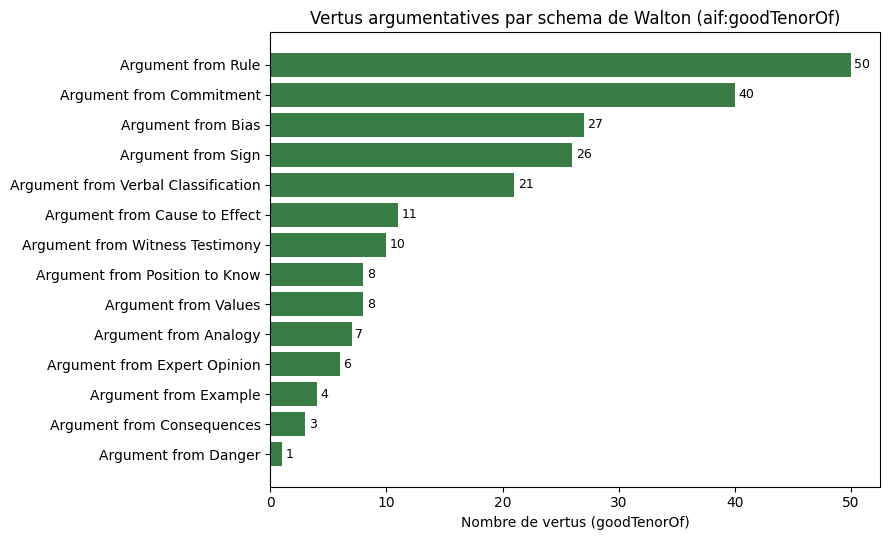

In [6]:
# --- Distribution des schemes de Walton portes par les vertus + graphique ---
%matplotlib inline
import matplotlib.pyplot as plt

q_scheme = SKOS_P + """
PREFIX aif: <http://www.arg.dundee.ac.uk/aif#>
SELECT ?scheme (COUNT(?c) AS ?n) WHERE {
  ?c aif:goodTenorOf ?scheme .
} GROUP BY ?scheme ORDER BY DESC(?n)"""
rows = [(str(r.scheme), int(r.n)) for r in g.query(q_scheme)]
print(f"Schemes de Walton distincts portes par les vertus : {len(rows)}")
for s, n in rows:
    print(f"  {n:>3}  {s}")

labels = [s for s, _ in rows][::-1]
values = [n for _, n in rows][::-1]
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(labels, values, color="#3a7d44")
ax.set_xlabel("Nombre de vertus (goodTenorOf)")
ax.set_title("Vertus argumentatives par schema de Walton (aif:goodTenorOf)")
for i, v in enumerate(values):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()


**Lecture** : les **14 schemes** de Walton relies aux vertus sont exactement ceux qui
apparaissent cote sophismes. Les plus productifs -- *Argument from Rule* (50 vertus), *from
Commitment* (40), *from Bias* (27), *from Sign* (26) -- sont les schemes ou l'argumentation
correcte se decline en de nombreuses bonnes pratiques. La propriete `goodTenorOf` est donc le
**pivot** qui permettra, dans les exercices, de relier une vertu a son sophisme miroir via le
schema partage.


## 7. Exercices

Trois exercices pour manipuler le thesaurus vous-meme. Les cellules sont des squelettes a
completer -- le graphe `g` est deja charge en memoire.


### Exercice 1 -- Concepts sans definition dans une langue

Ecrire une requete SPARQL qui liste les concepts possedant un `skos:prefLabel` **anglais** mais
**aucune** `skos:definition` anglaise (candidats a la traduction). Indice : `FILTER NOT EXISTS`.


In [7]:
# Exercice 1 a completer
# Objectif : concepts avec prefLabel @en mais SANS definition @en.
# Indice : SPARQL FILTER NOT EXISTS { ?c skos:definition ?d . FILTER(lang(?d)="en") }

# q_ex1 = SKOS_P + """
# SELECT ?c WHERE {
#   ?c skos:prefLabel ?l . FILTER(lang(?l) = "en")
#   # ... a completer ...
# }"""
# resultats = list(g.query(q_ex1))
# print(f"{len(resultats)} concept(s) sans definition EN")

resultats = None  # TODO etudiant
print("Exercice 1 a completer")


Exercice 1 a completer


### Exercice 2 -- Visualiser une famille avec networkx

Choisir une tete de famille (p. ex. `credibleSources`) et dessiner son sous-arbre `narrower`
avec `networkx` + `matplotlib`. Indice : parcourir recursivement `g.objects(node, SKOS.narrower)`
et construire un `networkx.DiGraph`.


In [8]:
# Exercice 2 a completer
# Objectif : sous-arbre narrower d'une famille, dessine avec networkx.
# Indice :
#   import networkx as nx
#   G = nx.DiGraph()
#   def descendre(node):
#       for enfant in g.objects(node, SKOS.narrower): ...
#   nx.draw(G, with_labels=True)

racine_famille = None  # TODO etudiant : une URIRef de tete de famille
print("Exercice 2 a completer")


Exercice 2 a completer


### Exercice 3 -- Le pont vertus <-> sophismes

Pour un schema de Walton donne (p. ex. `"Argument from Sign"`), lister toutes les vertus qui en
sont le `goodTenorOf`. Bonus : ouvrir `Argument_Analysis_Ontology_AIF.ipynb` et comparer avec les
**sophismes** relies au **meme** schema -- vous materialisez ainsi l'axe good/bad tenor.


In [9]:
# Exercice 3 a completer
# Objectif : pour un scheme de Walton, lister les vertus goodTenorOf ; comparer au pole sophismes.
# Indice : construire une requete SPARQL avec le prefixe
#   PREFIX aif: <http://www.arg.dundee.ac.uk/aif#>
#   et un motif  ?c aif:goodTenorOf "Argument from Sign"  (l'objet est un litteral).

scheme_cible = "Argument from Sign"  # a explorer
vertus_du_scheme = None  # TODO etudiant
print("Exercice 3 a completer")


Exercice 3 a completer


## 8. Ponts avec la serie Argument_Analysis

- [`Argument_Analysis_Ontology_AIF`](Argument_Analysis_Ontology_AIF.ipynb) -- le **pole sophismes**
  (OWL2 ABox, schemes de Walton via `badTenorOf`). A lire en parallele : meme projet, paradigme oppose.
- [`Argument_Analysis_Ontology_CrossLinks`](Argument_Analysis_Ontology_CrossLinks.ipynb) -- les liens
  inter-noeuds systematises (CSV canonique multilingue).
- [`Argument_Analysis_Restitution_3_Actes`](Argument_Analysis_Restitution_3_Actes.ipynb) -- la
  restitution pedagogique en trois actes.

**A retenir** : une meme famille de connaissances (l'argumentation) peut se modeliser en
**ABox relationnel** (individus + relations, cote sophismes) ou en **thesaurus SKOS**
(concepts + hierarchie + multilingue, cote vertus). SKOS n'est pas "moins expressif" -- il est
**adapte a une taxonomie navigable et traduisible**, la ou l'ABox convient a un graphe dense de
relations. Le choix depend de l'usage vise, pas d'une hierarchie de valeur entre formalismes.
